In [ ]:
# Does the noise correction of the 3D asymmetry give back the noiseless value?
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

sys.path.insert(0, "/home2/s4636708/master_thesis_project/src")
from galaxy_sidm.mock import load_galaxy_gas, CubeParams, build_cube
from galaxy_sidm.mock.asymmetry import asymmetry_3d
from galaxy_sidm.mock.residuals import cube_noise, N_EDGE

MARTINI = Path("/scratch/s4636708/aida/derived/martini")
TWINS = Path("/scratch/s4636708/aida/derived/tmp/noiseless_cubes") # built once: ~2 min at 138 px, ~9 min at 272 px
RUNS = {"CDM": "/scratch/s4636708/aida/L35n1080_CDM/output",      # CDM z4 cubes were made from the shadow tree
        "SIDM1": "/scratch/s4636708/aida/L35n1080_SIDM1/output",  # (config paths.shadow_cdm), not handled here
        "vSIDM": "/scratch/s4636708/aida/L35n1080_vSIDM_correa/output"}
Z_SNAP = {5: 17, 4: 21, 3: 25, 2: 33, 1: 50, 0.5: 67}
NCPU = 8
N_NOISE = 100 # more noise realisations: the cube's own noise field, shifted
# calibration galaxies (CDM z0.5), one per class, from symmetric to lopsided
GALAXIES = [("CDM", 0.5, 89227, "disc"), ("CDM", 0.5, 83331, "unsure"), ("CDM", 0.5, 75244, "perturbed")]

In [2]:
def gal_dir(model, z, sub):
    return MARTINI / f"z{z:g}" / model / f"gal_{sub:06d}"

def twin(model, z, sub):
    """Noiseless twin of <gal>/cube.fits (same gas, FOV and beam, no noise), built on first use."""
    out = TWINS / f"{model}_z{z:g}_{sub:06d}.fits"
    if not out.exists():
        info = json.loads((gal_dir(model, z, sub) / "info.json").read_text())
        gas = load_galaxy_gas(RUNS[model], Z_SNAP[z], sub)
        build_cube(gas, out, CubeParams(add_noise=False, half_kpc=info["cube_half_kpc"]), ncpu=NCPU)
    return out

def load(path):
    return np.nan_to_num(np.asarray(fits.getdata(path), float))

def edge_sigma(cube):
    """The pipeline's sigma: std of the N_EDGE first and last channels (residuals.cube_noise)."""
    return np.concatenate([cube[:N_EDGE].ravel(), cube[-N_EDGE:].ravel()]).std()

# check: cube.fits - twin must be pure noise: independent of the signal (slope 0), with the cube's sigma
rows = []
for model, z, sub, cls in GALAXIES:
    D, S = load(gal_dir(model, z, sub) / "cube.fits"), load(twin(model, z, sub))
    n = D - S
    rows.append(dict(subID=sub, cls=cls, npix=D.shape[-1], sigma_edge=cube_noise(gal_dir(model, z, sub)),
                     sigma_true=n.std(), slope=np.polyfit(S.ravel(), n.ravel(), 1)[0]))
pd.DataFrame(rows)

,subID,cls,npix,sigma_edge,sigma_true,slope
0,89227,disc,138,0.003553,0.003567,-0.001846
1,83331,unsure,272,0.002665,0.002682,0.001143
2,75244,perturbed,138,0.000046,0.000046,0.003525


In [ ]:
rng = np.random.default_rng(0)
rows = []
for model, z, sub, cls in GALAXIES:
    g = gal_dir(model, z, sub)
    D, S = load(g / "cube.fits"), load(twin(model, z, sub))
    clean = asymmetry_3d(g, cube=S, sigma=0.0) # noiseless twin
    raw = asymmetry_3d(g, sigma=0.0) # cube.fits, but no noise correction (sigma=0)
    noisy = asymmetry_3d(g) # cube.fits, with noise correction (sigma from the cube's end channels)
    shifted = []
    for _ in range(N_NOISE):
        c = S + np.roll(D - S, [rng.integers(m) for m in D.shape], axis=(0, 1, 2))
        shifted.append(asymmetry_3d(g, cube=c, sigma=edge_sigma(c)))
    lin, sq = np.array([a.A_corr for a in shifted]), np.array([a.A_sq for a in shifted])
    rows.append(dict(subID=sub, cls=cls,
                     lin_noiseless=clean.A, lin_noisy=raw.A, lin_noisy_corr=noisy.A_corr,
                     lin_shifted=lin.mean(), lin_shifted_std=lin.std(),
                     sq_noiseless=clean.A_sq, sq_noisy=raw.A_sq, sq_noisy_corr=noisy.A_sq,
                     sq_shifted=sq.mean(), sq_shifted_std=sq.std()))
test = pd.DataFrame(rows)
test.round(4)

,subID,cls,lin_noiseless,lin_noisy,lin_noisy_corr,lin_shifted,lin_shifted_std,sq_noiseless,sq_noisy,sq_noisy_corr,sq_shifted,sq_shifted_std
0,89227,disc,0.2417,0.2750,0.1767,0.1700,0.0069,0.0528,0.0623,0.0561,0.0528,0.0030
1,83331,unsure,0.5730,0.6101,0.4828,0.4579,0.0054,0.3600,0.3797,0.3724,0.3594,0.0052
2,75244,perturbed,0.9745,0.9674,0.7890,0.7880,0.0177,0.9681,0.9591,0.9581,0.9608,0.0267


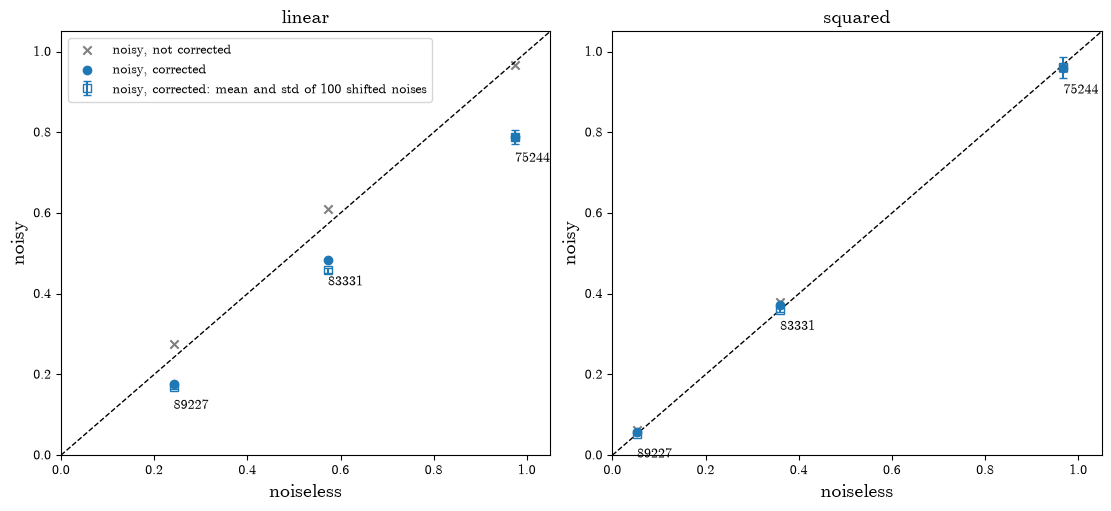

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, kind, title in zip(axes, ("lin", "sq"), ("linear", "squared")):
    x = test[f"{kind}_noiseless"]
    ax.plot([0, 1.05], [0, 1.05], "k--", lw=1)
    ax.scatter(x, test[f"{kind}_noisy"], marker="x", c="grey", label="noisy, not corrected")
    ax.scatter(x, test[f"{kind}_noisy_corr"], zorder=3, label="noisy, corrected")
    ax.errorbar(x, test[f"{kind}_shifted"], yerr=test[f"{kind}_shifted_std"], fmt="s", mfc="none",
                capsize=3, label=f"noisy, corrected: mean and std of {N_NOISE} shifted noises")
    for xi, yi, sub in zip(x, test[f"{kind}_noisy_corr"], test["subID"]):
        ax.annotate(str(sub), (xi, yi), textcoords="offset points", xytext=(0, -18), fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("noiseless", fontsize=14)
    ax.set_ylabel("noisy", fontsize=14)
    ax.set_title(title, fontsize=14)
axes[0].legend(fontsize=10, loc="upper left")
plt.show()